# How the detectors compare on simulated sessions

Every detector in `ripple_detection`, at its defaults, on sessions from `simulate_session`: pink (1/f) noise, ripples of known time, duration (40-120 ms) and frequency (150-250 Hz) sized by `ripple_snr` (their peak after ripple-band filtering, in units of the filtered background's SD), channels that share half their noise, a stratum radiatum channel carrying a sharp wave under each ripple for the Long detector, and a population of Poisson units that burst with each ripple for the Carey and HSE detectors.

The sweep is `simulation_study.py` beside this notebook (`uv run python examples/simulation_study.py`, about two minutes); it writes `simulation_study_results.csv`, which this notebook reads. Conditions:

- **ripples**: 40 ripples in 120 s, `ripple_snr` 1.5 to 6, 4, 16 or 32 channels (channel 0 at gain 1, the others at gains drawn between 0.5 and 1), three seeds, 100 units.
- **noise only**: the same sessions with no ripples, for the false-positive rate.
- **partial carriers**: 32 channels of which only a quarter or half carry the ripple, the rest noise only.
- **threshold sweep**: Kay, Karlsson and Zugaro at several thresholds on the 16-channel sessions, so the detectors can be compared at a matched false-positive rate.
- **sparse population**: 20 units instead of 100, for the spike detectors.
- **artifacts**: 40 ripples at `ripple_snr` 3 plus 20 common-mode broadband bursts.

An event counts as a hit when it overlaps the ripple's window (centre ± half the duration, where the envelope is at 1 percent of its peak). **Recall** is the fraction of ripples hit; **precision** the fraction of events that hit a ripple; **onset error** the median of event start minus window start over hit ripples, so negative is early.

What this can and cannot show is in the last section.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ripple_detection as rd

path = Path("simulation_study_results.csv")
results = pd.read_csv(path if path.exists() else Path("examples") / path)
SHORT = {
    "Kay_ripple_detector": "Kay", "Karlsson_ripple_detector": "Karlsson", "Roumis_ripple_detector": "Roumis",
    "Shvartsman_ripple_detector": "Shvartsman", "Yu_ripple_detector": "Yu", "Zugaro_ripple_detector": "Zugaro",
    "Long_sharp_wave_ripple_detector": "Long", "Carey_candidate_detector": "Carey", "multiunit_HSE_detector": "HSE",
}
ORDER = list(SHORT.values())
results["detector"] = results.detector.map(SHORT)
results["error"] = results.error.fillna("")
ripples = results[results.condition == "ripples"]
print(f"{len(results)} rows; rows where a detector raised: {results.error.ne('').sum()}")
results[results.error.ne("")][["condition", "n_channels", "detector", "error"]].drop_duplicates(["detector", "error"])

801 rows; rows where a detector raised: 0


,condition,n_channels,detector,error


## Recall and precision against ripple size, by channel count

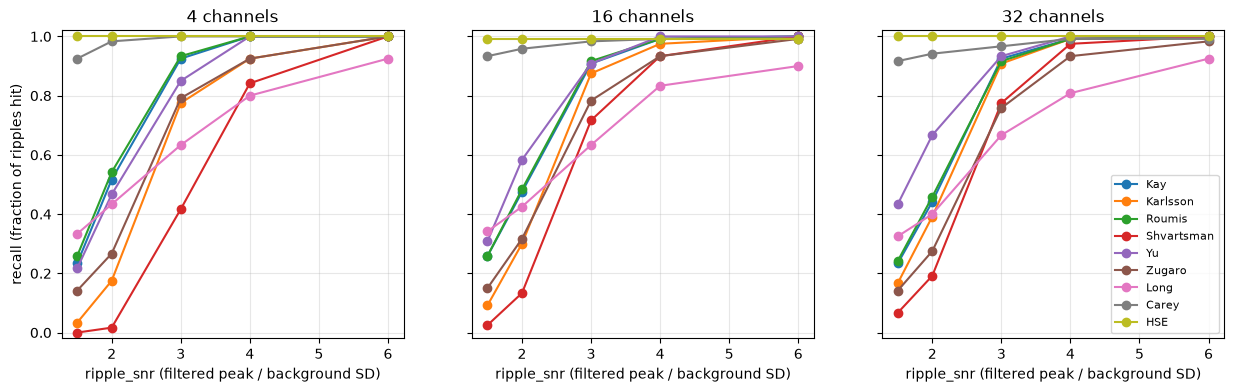

In [2]:
def curves(metric, ylabel):
    counts = sorted(ripples.n_channels.unique())
    fig, axes = plt.subplots(1, len(counts), figsize=(5 * len(counts), 4), sharey=True)
    for ax, n_channels in zip(axes, counts):
        table = (
            ripples[ripples.n_channels == n_channels]
            .pivot_table(index="ripple_snr", columns="detector", values=metric, aggfunc="mean")
            .reindex(columns=ORDER)
        )
        for detector in ORDER:
            ax.plot(table.index, table[detector], marker="o", label=detector)
        ax.set_title(f"{n_channels} channels")
        ax.set_xlabel("ripple_snr (filtered peak / background SD)")
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)
    axes[-1].legend(loc="lower right", fontsize=8)
    return fig

curves("recall", "recall (fraction of ripples hit)");

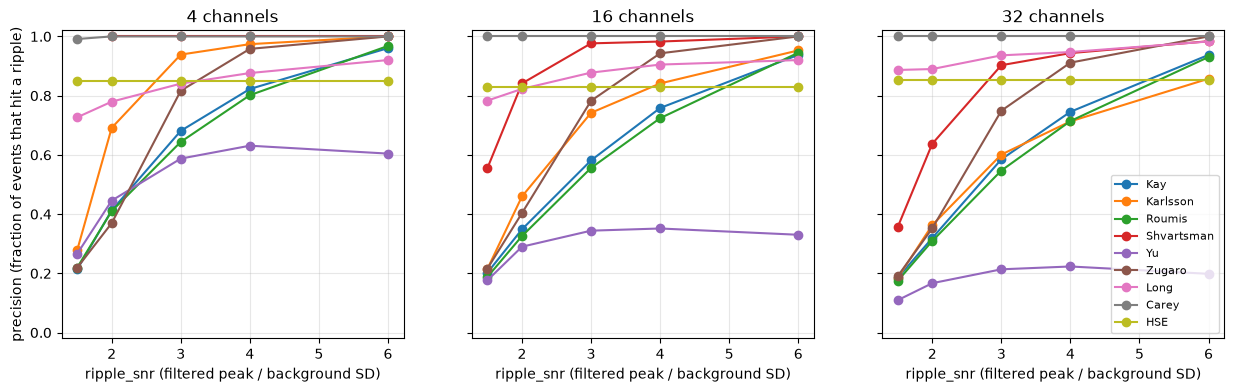

In [3]:
curves("precision", "precision (fraction of events that hit a ripple)");

## False positives on ripple-free sessions, by channel count

In [4]:
noise = results[results.condition == "noise only"]
minutes = 2.0
fp_per_minute = (
    noise.pivot_table(index="detector", columns="n_channels", values="n_events", aggfunc="mean") / minutes
).reindex(ORDER).round(1)
fp_per_minute.columns = [f"{c} ch" for c in fp_per_minute.columns]
fp_per_minute

,4 ch,16 ch,32 ch
detector,,,
Kay,18.0,21.2,23.5
Karlsson,2.0,8.8,18.5
Roumis,20.7,22.8,26.0
Shvartsman,0.0,0.7,2.0
Yu,15.2,24.5,70.3
Zugaro,10.8,13.7,16.0
Long,7.8,8.2,8.3
Carey,0.7,0.5,0.2
HSE,50.2,49.8,52.7


## When only some channels carry the ripple (32 channels)

In [5]:
partial = results[results.condition == "partial carriers"]
full = ripples[ripples.n_channels == 32]
tables = {}
for snr in sorted(partial.ripple_snr.unique()):
    for metric in ("recall", "precision"):
        table = partial[partial.ripple_snr == snr].pivot_table(
            index="detector", columns="carrier_fraction", values=metric, aggfunc="mean"
        )
        table[1.0] = full[full.ripple_snr == snr].groupby("detector")[metric].mean()
        table.columns = [f"{int(100 * c)} % of channels" for c in table.columns]
        tables[(f"ripple_snr {snr:g}", metric)] = table.reindex(ORDER)
pd.concat(tables, axis=1).round(2)

ripple_snr 3                                     \
                     recall                                      
           25 % of channels 50 % of channels 100 % of channels   
detector                                                         
Kay                    0.14             0.62              0.92   
Karlsson               0.64             0.79              0.91   
Roumis                 0.11             0.48              0.92   
Shvartsman             0.48             0.62              0.78   
Yu                     0.17             0.62              0.93   
Zugaro                 0.07             0.26              0.76   
Long                   0.61             0.61              0.67   
Carey                  0.86             0.91              0.97   
HSE                    0.98             0.98              1.00   

                                                                \
                  precision                                      
           25 % of channels 50 % of channels 100 % of channels   
detector                                                         
Kay                    0.12             0.43              0.59   
Karlsson               0.46             0.54              0.60   
Roumis                 0.09             0.34              0.55   
Shvartsman             0.86             0.90              0.90   
Yu                     0.05             0.17              0.21   
Zugaro                 0.15             0.45              0.75   
Long                   0.86             0.86              0.94   
Carey                  0.99             1.00              1.00   
HSE                    0.87             0.87              0.85   

               ripple_snr 6                                     \
                     recall                                      
           25 % of channels 50 % of channels 100 % of channels   
detector                                                         
Kay                    0.99             1.00              1.00   
Karlsson               1.00             1.00              1.00   
Roumis                 0.82             1.00              1.00   
Shvartsman             1.00             1.00              1.00   
Yu                     0.26             0.99              1.00   
Zugaro                 0.75             0.96              0.98   
Long                   0.94             0.94              0.92   
Carey                  0.94             0.96              0.99   
HSE                    0.98             0.98              1.00   

                                                                
                  precision                                     
           25 % of channels 50 % of channels 100 % of channels  
detector                                                        
Kay                    0.62             0.78              0.94  
Karlsson               0.60             0.66              0.86  
Roumis                 0.49             0.70              0.93  
Shvartsman             0.95             0.98              0.98  
Yu                     0.07             0.26              0.20  
Zugaro                 0.80             0.99              1.00  
Long                   0.92             0.92              0.98  
Carey                  1.00             1.00              1.00  
HSE                    0.87             0.87              0.85

## Comparing at a matched false-positive rate (16 channels)

Kay                                        \
                recall at snr 3 recall at snr 4 false positives / min   
threshold_value                                                         
2.0                        0.91            0.99                 21.17   
2.5                        0.85            0.98                  7.33   
3.0                        0.76            0.94                  1.50   
3.5                        0.57            0.91                  0.17   
4.0                        0.36            0.86                  0.00   
5.0                        0.14            0.58                  0.00   
6.0                         NaN             NaN                   NaN   
8.0                         NaN             NaN                   NaN   

                       Karlsson                                        \
                recall at snr 3 recall at snr 4 false positives / min   
threshold_value                                                         
2.0                        0.98            1.00                164.33   
2.5                        0.93            1.00                 45.17   
3.0                        0.88            0.98                  8.83   
3.5                        0.67            0.94                  1.83   
4.0                        0.42            0.90                  0.33   
5.0                        0.07            0.52                  0.00   
6.0                         NaN             NaN                   NaN   
8.0                         NaN             NaN                   NaN   

                         Zugaro                                        
                recall at snr 3 recall at snr 4 false positives / min  
threshold_value                                                        
2.0                         NaN             NaN                   NaN  
2.5                         NaN             NaN                   NaN  
3.0                        0.88            0.93                 56.83  
3.5                         NaN             NaN                   NaN  
4.0                        0.84            0.93                 29.67  
5.0                        0.78            0.93                 13.67  
6.0                        0.66            0.92                  5.50  
8.0                        0.37            0.72                  0.83

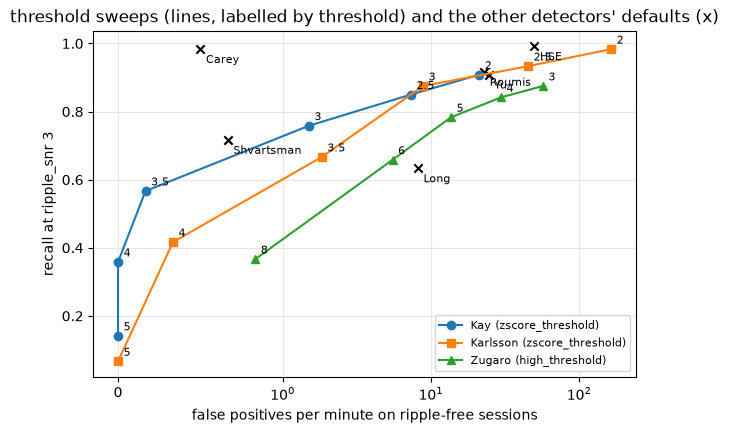

In [6]:
sweep = results[results.condition == "threshold sweep"]
fig, ax = plt.subplots(figsize=(7, 4.5))
summary = {}
for detector, marker in zip(["Kay", "Karlsson", "Zugaro"], ["o", "s", "^"]):
    sub = sweep[sweep.detector == detector]
    recall_3 = sub[sub.ripple_snr == 3.0].groupby("threshold_value").recall.mean()
    recall_4 = sub[sub.ripple_snr == 4.0].groupby("threshold_value").recall.mean()
    fp = sub[sub.ripple_snr.isna()].groupby("threshold_value").n_events.mean() / minutes
    ax.plot(fp, recall_3, marker=marker, label=f"{detector} ({sub.threshold_parameter.iloc[0]})")
    for value, x, y in zip(fp.index, fp, recall_3):
        ax.annotate(f"{value:g}", (x, y), textcoords="offset points", xytext=(4, 4), fontsize=8)
    summary[detector] = pd.DataFrame({"recall at snr 3": recall_3, "recall at snr 4": recall_4, "false positives / min": fp}).round(2)
# the other detectors at their defaults, for reference
defaults = ripples[(ripples.n_channels == 16) & (ripples.ripple_snr == 3.0)].groupby("detector").recall.mean()
default_fp = noise[noise.n_channels == 16].groupby("detector").n_events.mean() / minutes
for detector in ["Shvartsman", "Yu", "Roumis", "Long", "Carey", "HSE"]:
    ax.scatter(default_fp[detector], defaults[detector], marker="x", color="k")
    ax.annotate(detector, (default_fp[detector], defaults[detector]), textcoords="offset points", xytext=(4, -10), fontsize=8)
ax.set_xscale("symlog", linthresh=1.0)
ax.set_xlabel("false positives per minute on ripple-free sessions")
ax.set_ylabel("recall at ripple_snr 3")
ax.set_title("threshold sweeps (lines, labelled by threshold) and the other detectors' defaults (x)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
pd.concat(summary, axis=1)

## Where the events start and end, relative to the ripple (16 channels)

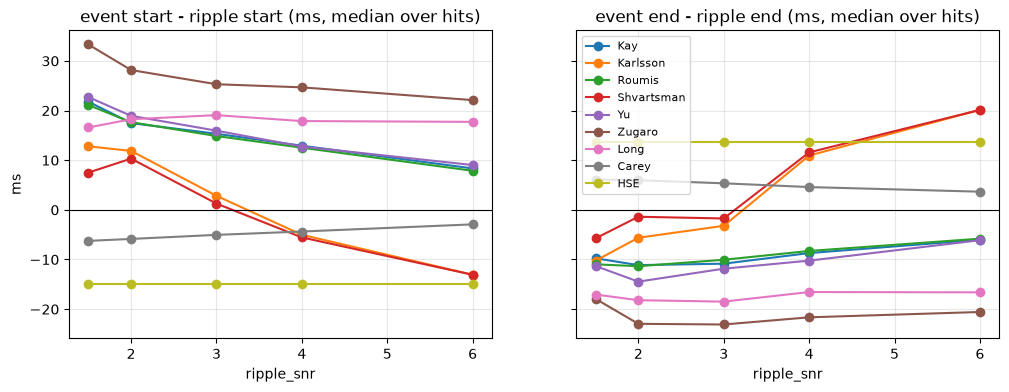

In [7]:
sixteen = ripples[ripples.n_channels == 16]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, metric, title in zip(axes, ["onset_ms", "offset_ms"], ["event start - ripple start", "event end - ripple end"]):
    table = sixteen.pivot_table(index="ripple_snr", columns="detector", values=metric, aggfunc="mean").reindex(columns=ORDER)
    for detector in ORDER:
        ax.plot(table.index, table[detector], marker="o", label=detector)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{title} (ms, median over hits)")
    ax.set_xlabel("ripple_snr")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("ms")
axes[-1].legend(fontsize=8);

## The spike detectors and the size of the population (16 channels, `ripple_snr` 4)

In [8]:
dense = ripples[(ripples.ripple_snr == 4.0) & (ripples.n_channels == 16)]
sparse = results[results.condition == "sparse population"]
spike = ["Carey", "HSE"]
pd.concat(
    {
        "100 units": dense[dense.detector.isin(spike)].groupby("detector")[["recall", "precision", "n_events"]].mean(),
        "20 units": sparse[sparse.detector.isin(spike)].groupby("detector")[["recall", "precision", "n_events"]].mean(),
    },
    axis=1,
).round(2)

100 units                    20 units                   
            recall precision n_events   recall precision n_events
detector                                                         
Carey         0.99      1.00    39.67     0.81      0.40    80.33
HSE           0.99      0.83    48.00     0.85      0.32   108.00

## Common-mode artifacts (16 channels, `ripple_snr` 3)

In [9]:
artifacts = results[results.condition == "artifacts"]
clean = ripples[(ripples.ripple_snr == 3.0) & (ripples.n_channels == 16)]
pd.concat(
    {
        "clean": clean.groupby("detector")[["recall", "precision"]].mean(),
        "with 20 artifacts": artifacts.groupby("detector")[["recall", "precision"]].mean(),
    },
    axis=1,
).reindex(ORDER).round(2)

clean           with 20 artifacts          
           recall precision            recall precision
detector                                               
Kay          0.91      0.58              0.00      0.00
Karlsson     0.88      0.74              0.01      0.02
Roumis       0.92      0.56              0.00      0.00
Shvartsman   0.72      0.98              0.00      0.00
Yu           0.91      0.34              0.88      0.30
Zugaro       0.78      0.78              0.00      0.00
Long         0.63      0.88              0.55      0.93
Carey        0.98      1.00              0.92      0.79
HSE          0.99      0.83              1.00      0.85

### Robust normalization under artifacts

The ripple-band detectors z-score their trace over the whole recording. Twenty artifacts with far more ripple-band power than any ripple inflate that standard deviation until the ripples sit below 2 SD, so recall collapses. `normalization_method="median_mad"` (Kay, Karlsson, Roumis, Shvartsman, HSE) scales by the median absolute deviation, which the artifacts do not inflate; the artifacts are then still detected as events, so precision needs a second step (an amplitude ceiling, or rejecting events present on a reference channel), but the ripples come back. One artifact session, Kay and Karlsson:

In [10]:
fs = 1500.0
time = rd.simulate_time(int(120 * fs), fs)
slots = np.arange(3.0, 118.0, 2.0)
ripple_times = slots[np.arange(slots.size) % 3 != 0]
artifact_times = slots[np.arange(slots.size) % 3 == 0]
session = rd.simulate_session(
    time, list(ripple_times), n_channels=16, n_units=100, ripple_snr=3.0,
    artifact_times=list(artifact_times), rng=11,
)
filtered = rd.filter_ripple_band(session.lfps, sampling_frequency=fs)

def hit_rates(events):
    windows = session.ripple_windows
    hits = [((events.start_time <= end) & (events.end_time >= start)).any() for start, end in windows]
    matched = np.zeros(len(events), dtype=bool)
    for start, end in windows:
        matched |= ((events.start_time <= end) & (events.end_time >= start)).to_numpy()
    return {"recall": np.mean(hits), "precision": matched.mean() if len(events) else np.nan, "events": len(events)}

rows = {}
for name, detector in [("Kay", rd.Kay_ripple_detector), ("Karlsson", rd.Karlsson_ripple_detector)]:
    for method in ("zscore", "median_mad"):
        events = detector(session.time, filtered, session.speed, fs, normalization_method=method)
        rows[(name, method)] = hit_rates(events)
pd.DataFrame(rows).T.round(2)

recall  precision  events
Kay      zscore        0.03       0.05    21.0
         median_mad    1.00       0.33   120.0
Karlsson zscore        0.03       0.05    21.0
         median_mad    0.92       0.51    68.0

## One session, five detectors

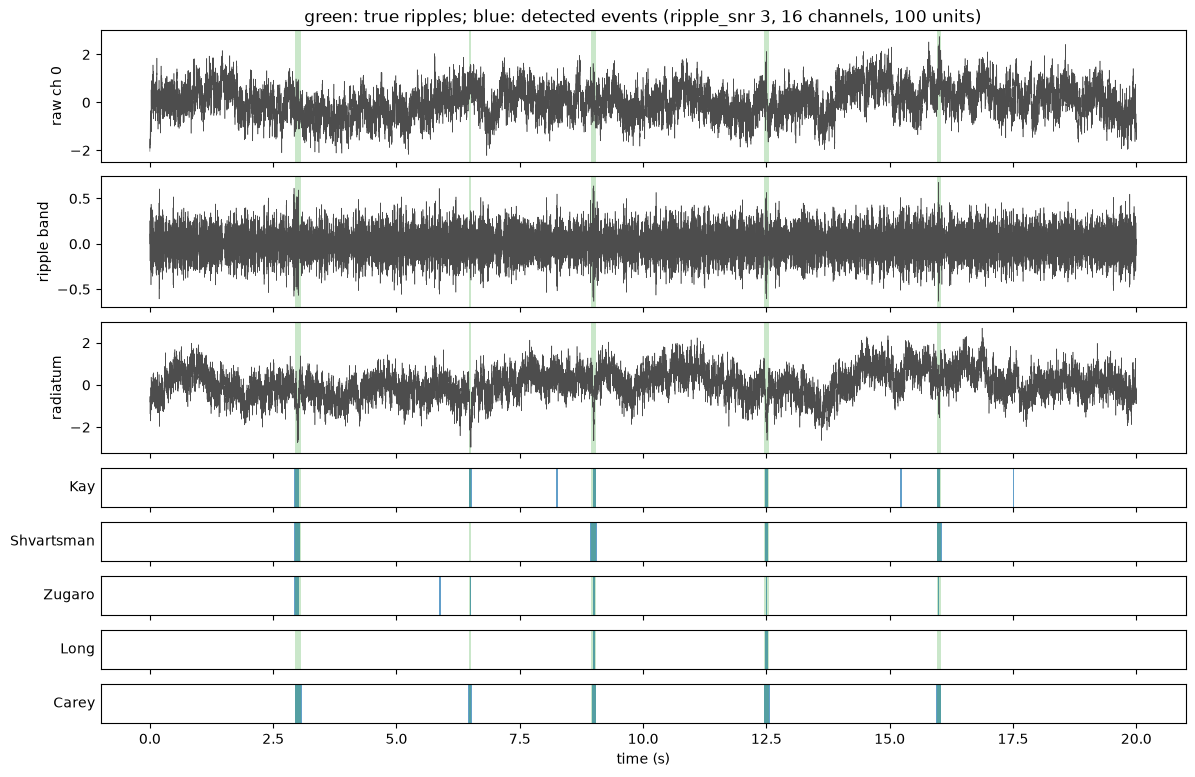

In [11]:
time = rd.simulate_time(int(20 * fs), fs)
session = rd.simulate_session(time, [3.0, 6.5, 9.0, 12.5, 16.0], n_channels=16, n_units=100, ripple_snr=3.0, rng=7)
filtered = rd.filter_ripple_band(session.lfps, sampling_frequency=fs)
detections = {
    "Kay": rd.Kay_ripple_detector(session.time, filtered, session.speed, fs),
    "Shvartsman": rd.Shvartsman_ripple_detector(session.time, filtered, session.speed, fs),
    "Zugaro": rd.Zugaro_ripple_detector(session.time, filtered, session.speed, fs),
    "Long": rd.Long_sharp_wave_ripple_detector(session.time, session.raw_lfp, session.speed, fs, sharp_wave_lfp=session.sharp_wave_lfp),
    "Carey": rd.Carey_candidate_detector(session.time, filtered, session.multiunit, session.speed, fs),
}
fig, axes = plt.subplots(3 + len(detections), 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 2, 2] + [0.6] * len(detections)})
axes[0].plot(time, session.lfps[:, 0], lw=0.4, color="0.3"); axes[0].set_ylabel("raw ch 0")
axes[1].plot(time, filtered[:, 0], lw=0.4, color="0.3"); axes[1].set_ylabel("ripple band")
axes[2].plot(time, session.sharp_wave_lfp, lw=0.4, color="0.3"); axes[2].set_ylabel("radiatum")
for ax in axes[:3]:
    for start, end in session.ripple_windows:
        ax.axvspan(start, end, color="tab:green", alpha=0.25, lw=0)
for ax, (name, events) in zip(axes[3:], detections.items()):
    for _, event in events.iterrows():
        ax.axvspan(event.start_time, event.end_time, color="tab:blue", alpha=0.7, lw=0)
    for start, end in session.ripple_windows:
        ax.axvspan(start, end, color="tab:green", alpha=0.25, lw=0)
    ax.set_yticks([]); ax.set_ylabel(name, rotation=0, ha="right", va="center")
axes[-1].set_xlabel("time (s)")
axes[0].set_title("green: true ripples; blue: detected events (ripple_snr 3, 16 channels, 100 units)");

## What this shows

- **The channel count changes the ranking.** With 4 channels Karlsson at 3 SD gave 2 false positives a minute; with 32 it gives 18, because any one of 32 channels crossing 3 SD makes an event. Yu's data-driven threshold falls further the more correlated channels feed its median, from 15 false positives a minute at 4 channels to 70 at 32. Kay, Roumis, Zugaro and Long barely change with channel count, and Shvartsman goes from 0 to 2. A recommendation for a 4-tetrode recording is not one for a 32-channel array.
- **At a matched false-positive rate the ripple-band algorithms are close, and Shvartsman trades a little recall for half the false positives.** On 16 channels, Kay at 3.0 SD (1.5 false positives a minute) and Karlsson at 3.5 (1.8) recall 0.76 and 0.67 of ripples at `ripple_snr` 3 and 0.94 at 4; Zugaro needs 8 SD to fall below one a minute (0.8), and then recalls 0.37 and 0.72. Shvartsman at its default recalls 0.72 at `ripple_snr` 3 and 0.93 at 4 with 0.7 false positives a minute: asking two channels to agree at 3 SD halves Kay's false-positive rate for 0.04 of its recall, and beats Karlsson at 3.5 SD on both. Differences between the defaults are mostly differences in where the threshold sits.
- **Which channels carry the ripple matters more than how many there are.** With the ripple on a quarter of 32 channels at `ripple_snr` 3, Karlsson recalls 0.64 and Shvartsman 0.48, while Yu (0.17), Kay (0.14), Roumis (0.11) and Zugaro (0.07) lose it: pooled traces are diluted by the silent channels, by the channel count for Kay's sum of squares and worse for Roumis's mean of envelopes, and a median cannot see a ripple on a minority of channels at any amplitude (Yu recalls 0.26 at `ripple_snr` 6). Karlsson's per-channel rule is the only one that does not pay for silent channels; its price is inheriting every channel's noise.
- **The spike detectors' recall is set by the population burst, not the LFP.** Carey and HSE find 86 to 100 percent of ripples at every `ripple_snr` and with any fraction of carrying channels, because the units burst regardless. Their precision is set by the population: with 20 units instead of 100 it falls from 1.0 to 0.40 (Carey) and from 0.83 to 0.32 (HSE). HSE at 2 SD produces 50 events a minute on ripple-free sessions; it is a candidate generator. Carey is the slowest detector, about 2 s per 120 s of data.
- **Long's recall plateaus near 0.9 by construction**: its percentile cuts drop the weakest tenth of the sharp-wave cluster and it does not evaluate a candidate within 5 s of a block edge. Its events mark the sharp wave, so they start about 18 ms after the ripple window starts and end 17 ms before it ends. Its precision is high because a ripple without a sharp wave, or a common-mode artifact, does not qualify, and it is indifferent to how many pyramidal channels carry the ripple, since it reads one.
- **Common-mode artifacts silence the ripple-band detectors at their defaults, except Yu.** Twenty broadband bursts, each with far more ripple-band power than a ripple, inflate the z-scoring until every ripple falls below threshold: Kay, Karlsson, Roumis, Shvartsman and Zugaro recall nothing or next to it (Karlsson 0.01). Yu keeps 0.88 recall because its threshold is read off the noise side of the histogram, which the artifacts do not move; that is the one condition where its estimator is the right tool. Long cancels the artifacts in its channel difference and the spike detectors barely notice them. `normalization_method="median_mad"` brings Kay's and Karlsson's recall back (the session above), and the artifacts are then detected as events, so precision needs a second step: an amplitude ceiling, or rejecting events that also appear on a channel outside the hippocampus.
- **Where events start and end** depends on the rule, not only on the ripple. Kay, Roumis and Yu extend each event to where the trace returns to its mean, which lands 8 to 13 ms inside the window where the envelope is at 1 percent of its peak; Karlsson and Shvartsman merge per-channel events and land 5 to 12 ms outside it; Zugaro's power crossings sit 22 to 25 ms inside; the population burst HSE marks starts 15 ms before it.

## What it cannot show

The simulator's ripples are sinusoids under a Gaussian envelope, its sharp wave a Gaussian deflection, its units Poisson processes that all burst with the same envelope, its noise stationary 1/f with no theta, gamma or state changes, and its artifacts white bursts identical on every channel. Every ripple has a sharp wave and a population burst, which builds in the advantage of the detectors that read them. These numbers rank the defaults and expose their mechanics, dilution by silent channels, per-channel against pooled rules, normalization inflated by whatever else is in the recording; they are not the recall or precision to expect on a recording, and they say nothing about events a recording contains that the simulator does not produce. To ask a question the sweep does not, change the parameters of `simulate_session` (channel gains, `shared_noise_fraction`, `ripple_duration`, `ripple_frequency`, `n_units`, `participation`, `artifact_amplitude`) or of the detectors in `simulation_study.py` and rerun it.